In [2]:
from load_intan_rhd_format import read_data
import numpy as np

# 1. Load the entire file structure
filename = "rhd-data/adapter-air-baseline_125119.rhd"
result = read_data(filename)

# 2. Extract the key components
# 'amplifier_data' is a 2D numpy array: (Number of Channels, Number of Samples)
all_channels_data = result['amplifier_data'] 

# Intan stores data in microvolts (uV) by default in the 'result' dict
# Let's say you want to analyze channel 0
data_ch0 = all_channels_data[0, :]

# 3. Get the sampling frequency (very important for your PSD analysis)
fs = result['frequency_parameters']['amplifier_sample_rate']

print(f"Loaded {all_channels_data.shape[0]} channels.")
print(f"Sampling Rate: {fs} Hz")
print(f"Duration: {len(data_ch0)/fs:.2f} seconds")


Reading Intan Technologies RHD Data File, Version 3.3

Found 32 amplifier channels.
Found 3 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 16.273 seconds of data.  Amplifiers were sampled at 30.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 0.3 seconds
Loaded 32 channels.
Sampling Rate: 30000.0 Hz
Duration: 16.27 seconds


In [3]:
import os
import numpy as np
from load_intan_rhd_format import read_data

def batch_convert_rhd_to_npy(input_dir, output_dir, target_channels=['C-001', 'C-002', 'C-003', 'C-004']):
    """
    Finds all .rhd files in input_dir, extracts specific channels, 
    and saves them as t x 4 .npy files in output_dir.
    """
    # 1. Create output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")

    # 2. Get list of all .rhd files
    files = [f for f in os.listdir(input_dir) if f.endswith('.rhd')]
    
    if not files:
        print(f"No .rhd files found in {input_dir}")
        return

    print(f"Found {len(files)} files. Starting conversion...")

    for filename in files:
        file_path = os.path.join(input_dir, filename)
        
        try:
            # 3. Load the Intan file
            print(f"Processing: {filename}...", end='\r')
            result = read_data(file_path)
            
            # 4. Identify the indices for C01, C02, C03, C04
            # Intan names them 'C-001', 'C-002', etc. in the metadata
            all_chan_info = result['amplifier_channels']
            all_data = result['amplifier_data']
            
            indices = []
            for target in target_channels:
                # Find the index where the native_channel_name matches our target
                idx = next((i for i, c in enumerate(all_chan_info) if c['native_channel_name'] == target), None)
                if idx is not None:
                    indices.append(idx)
                else:
                    print(f"\nWarning: Channel {target} not found in {filename}")

            if len(indices) < len(target_channels):
                print(f"Skipping {filename} due to missing channels.")
                continue

            # 5. Extract and reformat to t x 4
            # all_data[indices, :] is 4 x t -> .T makes it t x 4
            extracted_data = all_data[indices, :].T
            
            # 6. Save as .npy
            output_filename = filename.replace('.rhd', '.npy')
            output_path = os.path.join(output_dir, output_filename)
            np.save(output_path, extracted_data.astype(np.float32)) # float32 saves space
            
        except Exception as e:
            print(f"\nError processing {filename}: {e}")

    print("\nBatch conversion complete! Files are in:", output_dir)

# --- EXECUTION ---
if __name__ == "__main__":
    # Settings
    HOME_DIR = "rhd-data"       # Folder where your raw .rhd files are
    EXPORT_DIR = "processed-npy" # New folder for your .npy files
    
    # Intan usually uses 'C-001', 'C-002' format. 
    # Adjust if your Intan software labels them differently (e.g. 'C01')
    CHANNELS_TO_KEEP = ['C-001', 'C-002', 'C-003', 'C-004']

    batch_convert_rhd_to_npy(HOME_DIR, EXPORT_DIR, CHANNELS_TO_KEEP)

Created directory: processed-npy
Found 43 files. Starting conversion...
Processing: probe0-full-shield-UNPLUG-OFF-ON_164114.rhd...
Reading Intan Technologies RHD Data File, Version 3.3

Found 32 amplifier channels.
Found 3 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.002 seconds of data.  Amplifiers were sampled at 30.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 1.0 seconds
Processing: probe4-full-shield-EWL-high_162801.rhd...
Reading Intan Technologies RHD Data File, Version 3.3

Found 32 amplifier channels.
Found 3 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digi

In [4]:
import os
import numpy as np
from scipy import signal
from load_intan_rhd_format import read_data

def calculate_rms(data):
    return np.sqrt(np.mean(data**2))

def batch_convert_with_noise_report(input_dir, output_dir, target_channels=['C-001', 'C-002', 'C-003', 'C-004']):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    files = [f for f in os.listdir(input_dir) if f.endswith('.rhd')]
    
    print(f"{'File':<25} | {'Chan':<5} | {'LFP RMS (uV)':<12} | {'Spike RMS (uV)':<14}")
    print("-" * 65)

    for filename in files:
        file_path = os.path.join(input_dir, filename)
        
        try:
            result = read_data(file_path)
            fs = result['frequency_parameters']['amplifier_sample_rate']
            all_chan_info = result['amplifier_channels']
            all_data = result['amplifier_data']
            
            # Find indices for target channels
            indices = []
            for target in target_channels:
                idx = next((i for i, c in enumerate(all_chan_info) if c['native_channel_name'] == target), None)
                if idx is not None: indices.append(idx)

            if len(indices) < len(target_channels):
                continue

            # Extract data (4 x t)
            extracted_data = all_data[indices, :]

            # Setup Filters
            b_lfp, a_lfp = signal.butter(4, [1, 300], btype='bandpass', fs=fs)
            b_spk, a_spk = signal.butter(4, [300, 3000], btype='bandpass', fs=fs)

            # Analyze each channel before saving
            for i, chan_label in enumerate(target_channels):
                raw_signal = extracted_data[i, :]
                
                # Apply filters
                lfp_sig = signal.filtfilt(b_lfp, a_lfp, raw_signal)
                spk_sig = signal.filtfilt(b_spk, a_spk, raw_signal)
                
                lfp_rms = calculate_rms(lfp_sig)
                spk_rms = calculate_rms(spk_sig)
                
                # Print row (only for the first file or every file as you prefer)
                print(f"{filename[:23]:<25} | {chan_label:<5} | {lfp_rms:^12.2f} | {spk_rms:^14.2f}")

            # Save as t x 4 .npy
            output_filename = filename.replace('.rhd', '.npy')
            # np.save(os.path.join(output_dir, output_filename), extracted_data.T.astype(np.float32))
            
        except Exception as e:
            print(f"Error in {filename}: {e}")

if __name__ == "__main__":
    batch_convert_with_noise_report("rhd-data", "processed-npy")

File                      | Chan  | LFP RMS (uV) | Spike RMS (uV)
-----------------------------------------------------------------

Reading Intan Technologies RHD Data File, Version 3.3

Found 32 amplifier channels.
Found 3 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.002 seconds of data.  Amplifiers were sampled at 30.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 0.9 seconds
probe0-full-shield-UNPL   | C-001 |     nan      |      2.68     
probe0-full-shield-UNPL   | C-002 |     nan      |      3.05     
probe0-full-shield-UNPL   | C-003 |     nan      |      4.37     
probe0-full-shield-UNPL   | C-004 |     nan      | 

In [5]:
import os
import numpy as np
from scipy import signal
from load_intan_rhd_format import read_data

def calculate_rms(data):
    return np.sqrt(np.mean(data**2))

def batch_convert_probes(input_dir, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    files = [f for f in os.listdir(input_dir) if f.endswith('.rhd')]
    
    print(f"{'File':<25} | {'Chan':<5} | {'LFP RMS (uV)':<12} | {'Spike RMS (uV)':<14}")
    print("-" * 65)

    for filename in files:
        # --- CONDITIONAL CHANNEL SELECTION ---
        if filename.startswith("probe0-"):
            # Channels 0, 1, 2, 3 -> C-000, C-001, C-002, C-003
            targets = [f"C-{i:03d}" for i in [0, 1, 2, 3]]
        elif filename.startswith("probe1-"):
            # Channels 12, 13, 14, 15 -> C-012, C-013, C-014, C-015
            targets = [f"C-{i:03d}" for i in [12, 13, 14, 15]]
        else:
            print(f"Skipping {filename}: Does not match 'probe0-' or 'probe1-' prefix.")
            continue

        file_path = os.path.join(input_dir, filename)
        
        try:
            result = read_data(file_path)
            fs = result['frequency_parameters']['amplifier_sample_rate']
            all_chan_info = result['amplifier_channels']
            all_data = result['amplifier_data']
            
            # Find indices for the specific targets for THIS file
            indices = []
            for t in targets:
                idx = next((i for i, c in enumerate(all_chan_info) if c['native_channel_name'] == t), None)
                if idx is not None: 
                    indices.append(idx)

            if len(indices) < len(targets):
                print(f"Error: Could not find all target channels in {filename}")
                continue

            # Extract data and filter
            extracted_data = all_data[indices, :]
            b_lfp, a_lfp = signal.butter(4, [1, 300], btype='bandpass', fs=fs)
            b_spk, a_spk = signal.butter(4, [300, 3000], btype='bandpass', fs=fs)

            for i, chan_label in enumerate(targets):
                raw_signal = extracted_data[i, :]
                lfp_rms = calculate_rms(signal.filtfilt(b_lfp, a_lfp, raw_signal))
                spk_rms = calculate_rms(signal.filtfilt(b_spk, a_spk, raw_signal))
                print(f"{filename[:23]:<25} | {chan_label:<5} | {lfp_rms:^12.2f} | {spk_rms:^14.2f}")

            # Save as t x 4 .npy
            output_filename = filename.replace('.rhd', '.npy')
            np.save(os.path.join(output_dir, output_filename), extracted_data.T.astype(np.float32))
            
        except Exception as e:
            print(f"Error in {filename}: {e}")

if __name__ == "__main__":
    batch_convert_probes("rhd-data", "processed-npy")

File                      | Chan  | LFP RMS (uV) | Spike RMS (uV)
-----------------------------------------------------------------

Reading Intan Technologies RHD Data File, Version 3.3

Found 32 amplifier channels.
Found 3 auxiliary input channels.
Found 0 supply voltage channels.
Found 0 board ADC channels.
Found 0 board digital input channels.
Found 0 board digital output channels.
Found 0 temperature sensors channels.

File contains 60.002 seconds of data.  Amplifiers were sampled at 30.00 kS/s.

Allocating memory for data...
Reading data from file...
10% done...
20% done...
30% done...
40% done...
50% done...
60% done...
70% done...
80% done...
90% done...
Parsing data...
No missing timestamps in data.
Done!  Elapsed time: 0.9 seconds
probe0-full-shield-UNPL   | C-000 |     nan      |      2.91     
probe0-full-shield-UNPL   | C-001 |     nan      |      2.68     
probe0-full-shield-UNPL   | C-002 |     nan      |      3.05     
probe0-full-shield-UNPL   | C-003 |     nan      | 

File: processed-npy/probe4-saline-miniscope-on_152941.npy
Shape: (789248, 4) (Time x Channels)
Duration: 26.31 seconds
Mean per channel: [-3.9863415 -3.2982519 -7.89142   -1.5674525]
Std (Noise) per channel: [70.08535  39.568527 55.20055  38.574596]


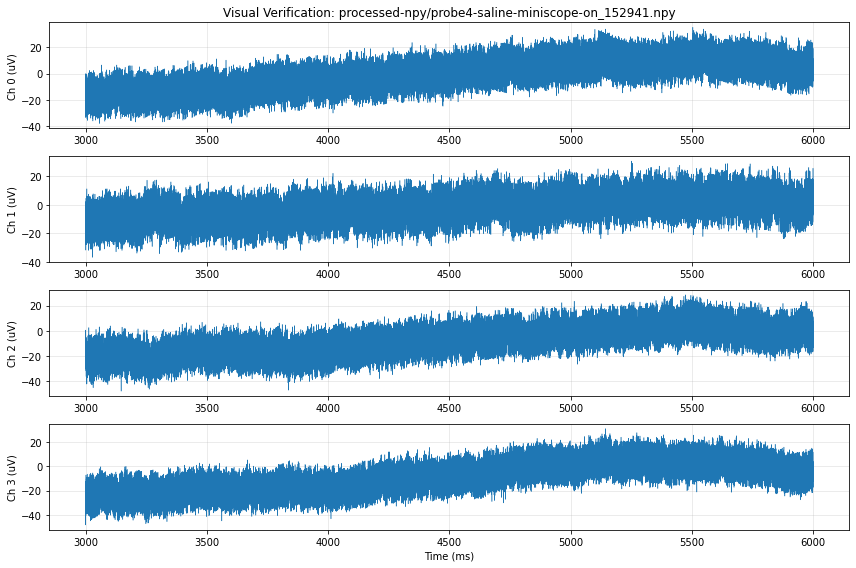

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the file
file_path = "processed-npy/probe4-saline-miniscope-on_152941.npy" # Update with an actual filename
data = np.load(file_path)

# 2. Check Shape and Basic Stats
# data.shape[0] is time (t), data.shape[1] is channels (4)
num_samples, num_channels = data.shape
fs = 30000  # Assuming 30kHz
duration = num_samples / fs

print(f"File: {file_path}")
print(f"Shape: {data.shape} (Time x Channels)")
print(f"Duration: {duration:.2f} seconds")
print(f"Mean per channel: {np.mean(data, axis=0)}")
print(f"Std (Noise) per channel: {np.std(data, axis=0)}")

# 3. Plot a 200ms snapshot to see the signal quality
start_sample = int(3 * fs)
end_sample = int(6 * fs) # 200ms
time_axis = np.arange(start_sample, end_sample) / fs * 1000 # in ms

plt.figure(figsize=(12, 8))
for i in range(num_channels):
    plt.subplot(num_channels, 1, i+1)
    plt.plot(time_axis, data[start_sample:end_sample, i], linewidth=0.5)
    plt.ylabel(f"Ch {i} (uV)")
    if i == 0:
        plt.title(f"Visual Verification: {file_path}")
    if i == num_channels - 1:
        plt.xlabel("Time (ms)")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()